# Statistical Anomaly Detection System

## Notebook 05: Alert Generation System

### Purpose

This notebook converts anomaly detection outputs into an interpretable alert framework for decision support.

### Objectives

- Categorize risk levels
- Generate anomaly alerts
- Summarize environmental risk
- Produce decision-support outputs

### Expected Outcome

A practical alert system capable of classifying observations into actionable risk categories.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

import os

os.makedirs("images", exist_ok=True)

In [4]:
df = pd.read_csv(
    "/content/Air Quality Data in India.csv",
    encoding="latin1",
    low_memory=False
)

pollutants = [
    "so2",
    "no2",
    "rspm",
    "spm"
]

air_quality = df[pollutants].copy()

for col in pollutants:

    air_quality[col] = (
        air_quality[col]
        .fillna(
            air_quality[col].median()
        )
    )

In [5]:
model = IsolationForest(
    contamination=0.01,
    random_state=42
)

model.fit(
    air_quality
)

air_quality["anomaly_score"] = (
    model.decision_function(
        air_quality
    )
)

## Risk Categorization

Anomaly scores are translated into interpretable environmental risk levels.

In [6]:
air_quality["risk_level"] = pd.qcut(
    air_quality["anomaly_score"],
    q=3,
    labels=[
        "High Risk",
        "Moderate Risk",
        "Low Risk"
    ]
)

In [7]:
risk_summary = (
    air_quality["risk_level"]
    .value_counts()
)

risk_summary

,count
risk_level,
High Risk,21340
Moderate Risk,21340
Low Risk,21340


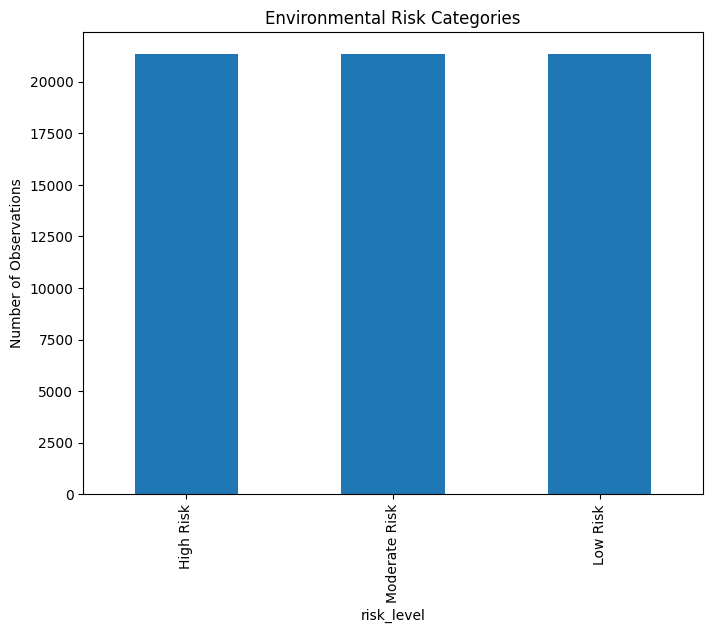

In [8]:
plt.figure(figsize=(8,6))

risk_summary.plot(
    kind="bar"
)

plt.title(
    "Environmental Risk Categories"
)

plt.ylabel(
    "Number of Observations"
)

plt.savefig(
    "images/risk_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
high_risk_alerts = (
    air_quality[
        air_quality["risk_level"]
        == "High Risk"
    ]
)

high_risk_alerts.head()

,so2,no2,rspm,spm,anomaly_score,risk_level
12,5.6,11.8,81.0,82.0,0.241435,High Risk
14,3.9,8.2,81.0,118.0,0.235062,High Risk
16,7.9,10.2,81.0,80.0,0.221667,High Risk
18,12.4,11.5,81.0,58.0,0.174594,High Risk
19,4.0,12.3,81.0,99.0,0.244085,High Risk


In [10]:
print(
    "Total High-Risk Alerts:",
    len(high_risk_alerts)
)

Total High-Risk Alerts: 21340


In [11]:
risk_summary.to_csv(
    "risk_summary.csv"
)

high_risk_alerts.to_csv(
    "high_risk_alerts.csv",
    index=False
)

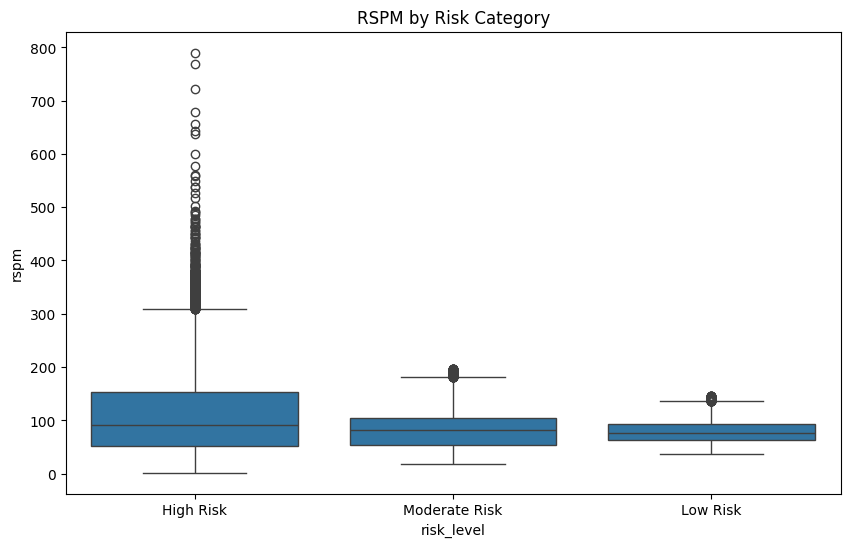

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="risk_level",
    y="rspm",
    data=air_quality
)

plt.title(
    "RSPM by Risk Category"
)

plt.savefig(
    "images/risk_category_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Findings

The anomaly scores were successfully translated into interpretable environmental risk categories.

The resulting framework provides a practical decision-support tool capable of identifying high-risk observations and generating alert outputs for further investigation.

The system demonstrates how statistical anomaly detection can be integrated into operational monitoring environments.